# ROCK-PAPER-SCISSORS: Multi-class Classification
## Comparing ALL Techniques: MLP → Augmentation → HOG → CNN → Transfer Learning

**Goal:** Maximize validation accuracy - no more constraints!

**Models Compared:**
1. Decision Tree (baseline)
2. Logistic Regression (baseline)
3. **MLP** - Feed-Forward Neural Network
4. **MLP + Data Augmentation** - More training data
5. **MLP + HOG Features** - Better features
6. **CNN** - Spatial learning
7. **Transfer Learning** - Pre-trained features

## 1. Setup and Imports

In [1]:
import sys
!{sys.executable} -m pip install -U scikit-learn

In [2]:
import sys
!{sys.executable} -m pip install -U scikit-image

In [3]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import os

# Import from src/ modules (no more local function definitions!)
from src.data import load_images_as_numpy
from src.models import build_mlp_model, build_cnn_model, build_transfer_model
from src.features import augment_dataset, extract_hog_features, apply_standard_scaler
from src.train import compile_model, get_callbacks
from src.eval import evaluate_model, plot_history

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd

print("TensorFlow version:", tf.__version__)
print("Keras version:", keras.__version__)

np.random.seed(42)
tf.random.set_seed(42)

TensorFlow version: 2.20.0
Keras version: 3.13.2


In [4]:
DATA_ROOT = "../data/rps"
IMG_H, IMG_W = 224, 224
BATCH_SIZE = 16
EPOCHS = 90
CLASSES = ['paper', 'rock', 'scissor']
NUM_CLASSES = len(CLASSES)

print(f"Data root: {DATA_ROOT}")
print(f"Image size: {IMG_H}x{IMG_W}")
print(f"Classes: {CLASSES}")

Data root: ../data/rps
Image size: 224x224
Classes: ['paper', 'rock', 'scissor']


## 2. Load Data as NumPy Arrays

In [5]:
print("Loading training data...")
X_train, y_train, class_names = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'train')
)

print("\nLoading validation data...")
X_val, y_val, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'val'),
    verbose=False
)

print("\nLoading test data...")
X_test, y_test, _ = load_images_as_numpy(
    os.path.join(DATA_ROOT, 'test'),
    verbose=False
)

print("\n" + "="*60)
print("DATA LOADED SUCCESSFULLY")
print("="*60)
print(f"Train set: {X_train.shape[0]} images, shape {X_train.shape[1:]}")
print(f"Validation set: {X_val.shape[0]} images, shape {X_val.shape[1:]}")
print(f"Test set: {X_test.shape[0]} images, shape {X_test.shape[1:]}")

print("\nClass distribution in training:")
for i, class_name in enumerate(CLASSES):
    count = np.sum(y_train == i)
    print(f"  {class_name}: {count} images ({count/len(y_train)*100:.1f}%)")

Loading training data...
Loading paper... 266 images
Loading rock... 267 images
Loading scissor... 265 images

Loading validation data...

Loading test data...

DATA LOADED SUCCESSFULLY
Train set: 798 images, shape (224, 224, 3)
Validation set: 199 images, shape (224, 224, 3)
Test set: 25 images, shape (224, 224, 3)

Class distribution in training:
  paper: 266 images (33.3%)
  rock: 267 images (33.5%)
  scissor: 265 images (33.2%)


## 3. Visualize Sample Images

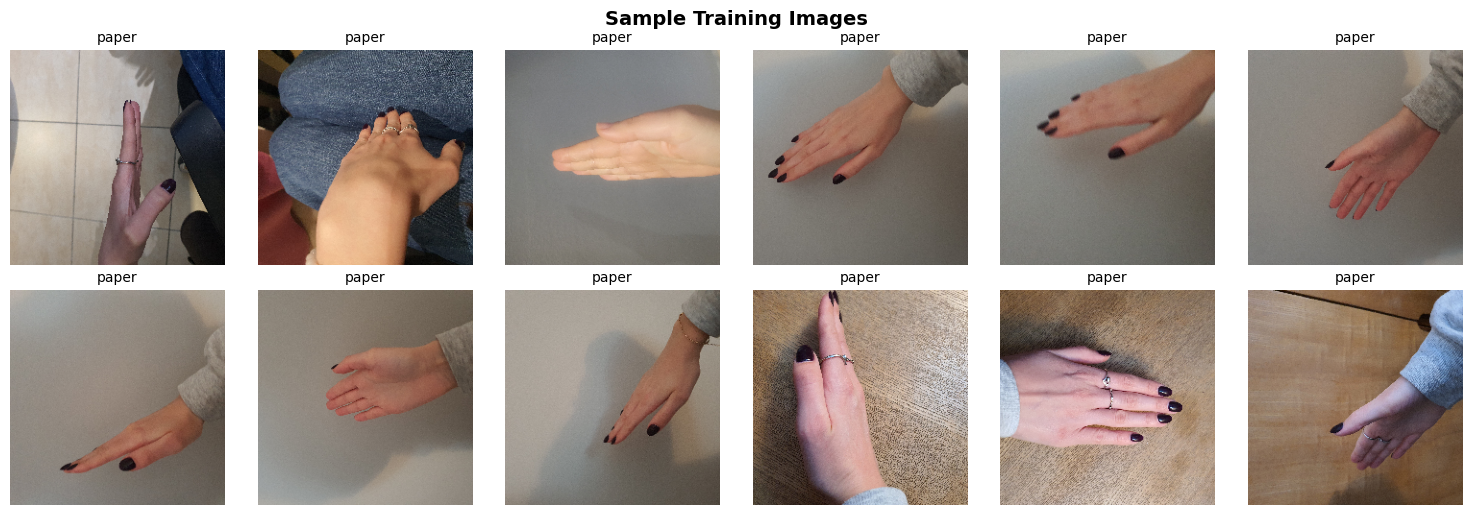

In [6]:
plt.figure(figsize=(15, 5))
for i in range(min(12, len(X_train))):
    plt.subplot(2, 6, i + 1)
    plt.imshow(X_train[i])
    plt.title(CLASSES[y_train[i]], fontsize=10)
    plt.axis('off')
plt.tight_layout()
plt.suptitle('Sample Training Images', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## 4. Prepare Data for MLP (Flatten)

In [7]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

print(f"Original shape: {X_train.shape}")
print(f"Flattened shape: {X_train_flat.shape}")
print(f"Each image is now a vector of {X_train_flat.shape[1]:,} features")

Original shape: (798, 224, 224, 3)
Flattened shape: (798, 150528)
Each image is now a vector of 150,528 features


In [8]:
# Apply StandardScaler for better MLP performance
print("Applying StandardScaler (zero mean, unit variance)...")
X_train_scaled, X_val_scaled, X_test_scaled, scaler = apply_standard_scaler(
    X_train_flat, X_val_flat, X_test_flat
)

print(f"\nBefore scaling:")
print(f"  Mean: {X_train_flat.mean():.4f}, Std: {X_train_flat.std():.4f}")
print(f"After scaling:")
print(f"  Mean: {X_train_scaled.mean():.4f}, Std: {X_train_scaled.std():.4f}")
print("StandardScaler improves MLP convergence by normalizing features!")

Applying StandardScaler (zero mean, unit variance)...

Before scaling:
  Mean: 0.4938, Std: 0.2346
After scaling:
  Mean: 0.0000, Std: 1.0000
StandardScaler improves MLP convergence by normalizing features!


## 5. Classical ML Baselines

In [9]:
print("Training Decision Tree...")
dt_model = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_model.fit(X_train_flat, y_train)
y_val_pred_dt = dt_model.predict(X_val_flat)
dt_acc = accuracy_score(y_val, y_val_pred_dt)
print(f"Decision Tree Validation Accuracy: {dt_acc:.2%}")

Training Decision Tree...
Decision Tree Validation Accuracy: 46.73%


In [10]:
print("Training Logistic Regression...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=0.1)
lr_model.fit(X_train_flat, y_train)
y_val_pred_lr = lr_model.predict(X_val_flat)
lr_acc = accuracy_score(y_val, y_val_pred_lr)
print(f"Logistic Regression Validation Accuracy: {lr_acc:.2%}")

Training Logistic Regression...
Logistic Regression Validation Accuracy: 61.81%


## 6. Baseline MLP Model (with StandardScaler)

In [11]:
mlp_model = build_mlp_model(X_train_scaled.shape[1], NUM_CLASSES)
mlp_model.summary()

Model: "MLP_Optimized"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 512)                 │      77,070,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 77,239,043 (294.64 MB)

 Trainable params: 77,237,251 (294.64 MB)

 Non-trainable params: 1,792 (7.00 KB)

TRAINING BASELINE MLP (with StandardScaler)
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 429ms/step - accuracy: 0.3697 - loss: 1.2919 - val_accuracy: 0.3568 - val_loss: 1.8220 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 429ms/step - accuracy: 0.4361 - loss: 1.1263 - val_accuracy: 0.4070 - val_loss: 1.3115 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.4887 - loss: 1.0554 - val_accuracy: 0.3819 - val_loss: 1.2554 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 428ms/step - accuracy: 0.5426 - loss: 0.9815 - val_accuracy: 0.4372 - val_loss: 1.1950 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.5752 - loss: 0.9127 - val_accuracy: 0.4372 - val_loss: 1.1595 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 427ms/step - accuracy: 0.6216 - loss: 0.8636 - val_accuracy: 0.4975 - val_loss: 1.1396 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 

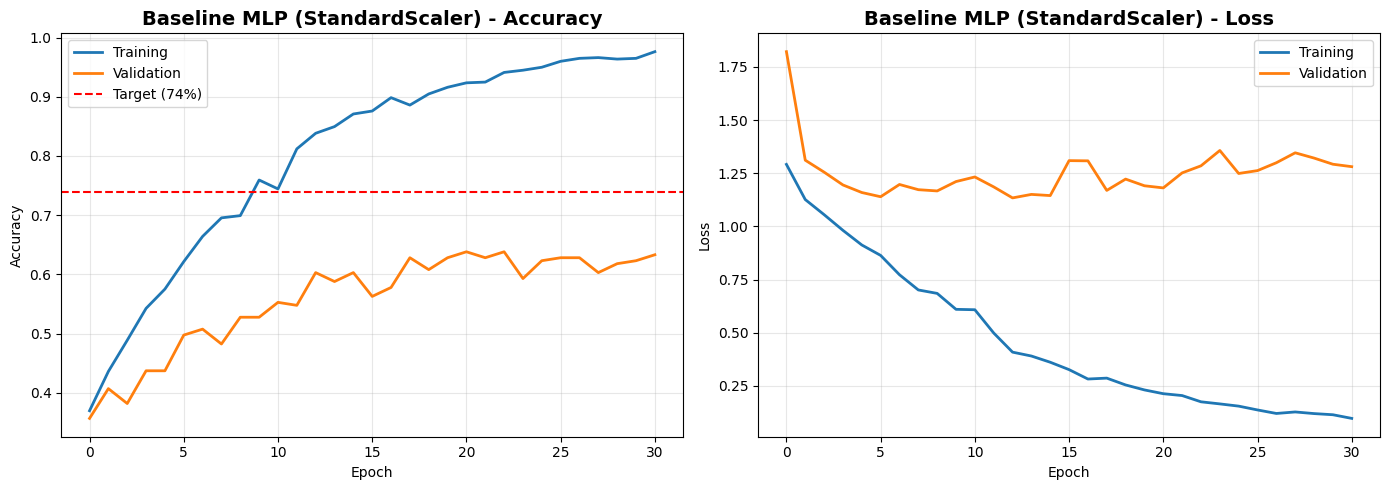

Best val accuracy: 63.82% at epoch 21


In [12]:
compile_model(mlp_model)
callbacks = get_callbacks()

print("="*70)
print("TRAINING BASELINE MLP (with StandardScaler)")
print("="*70)

history_mlp = mlp_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

mlp_val_loss, mlp_val_acc = mlp_model.evaluate(X_val_scaled, y_val, verbose=0)
print(f"\nBaseline MLP Validation Accuracy: {mlp_val_acc:.2%}")
plot_history(history_mlp, title="Baseline MLP (StandardScaler)")

## 7. MLP + Data Augmentation (with StandardScaler)

In [13]:
print("Augmenting training data...")
X_train_aug, y_train_aug = augment_dataset(X_train, y_train, augment_factor=2)
print(f"Original training size: {len(X_train)}")
print(f"Augmented training size: {len(X_train_aug)}")

X_train_aug_flat = X_train_aug.reshape(X_train_aug.shape[0], -1)

# Apply StandardScaler to augmented data
print("\nApplying StandardScaler to augmented data...")
X_train_aug_scaled, X_val_aug_scaled, X_test_aug_scaled, scaler_aug = apply_standard_scaler(
    X_train_aug_flat, X_val_flat, X_test_flat
)

Augmenting training data...
Original training size: 798
Augmented training size: 2394

Applying StandardScaler to augmented data...


TRAINING MLP + DATA AUGMENTATION (with StandardScaler)
Epoch 1/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 66s 422ms/step - accuracy: 0.3300 - loss: 1.2979 - val_accuracy: 0.2864 - val_loss: 1.1103 - learning_rate: 0.0010
Epoch 2/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 426ms/step - accuracy: 0.3279 - loss: 1.2017 - val_accuracy: 0.3216 - val_loss: 1.1093 - learning_rate: 0.0010
Epoch 3/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 426ms/step - accuracy: 0.3425 - loss: 1.1585 - val_accuracy: 0.3216 - val_loss: 1.1191 - learning_rate: 0.0010
Epoch 4/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 427ms/step - accuracy: 0.3571 - loss: 1.1524 - val_accuracy: 0.3467 - val_loss: 1.1158 - learning_rate: 0.0010
Epoch 5/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 64s 428ms/step - accuracy: 0.3488 - loss: 1.1400 - val_accuracy: 0.3819 - val_loss: 1.1136 - learning_rate: 0.0010
Epoch 6/90
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 451ms/step - accuracy: 0.3563 - loss: 1.1245 - val_accuracy: 0.4422 - val_loss: 1.1005 - learning_rate: 0.0010
Epoch 7/90
150/

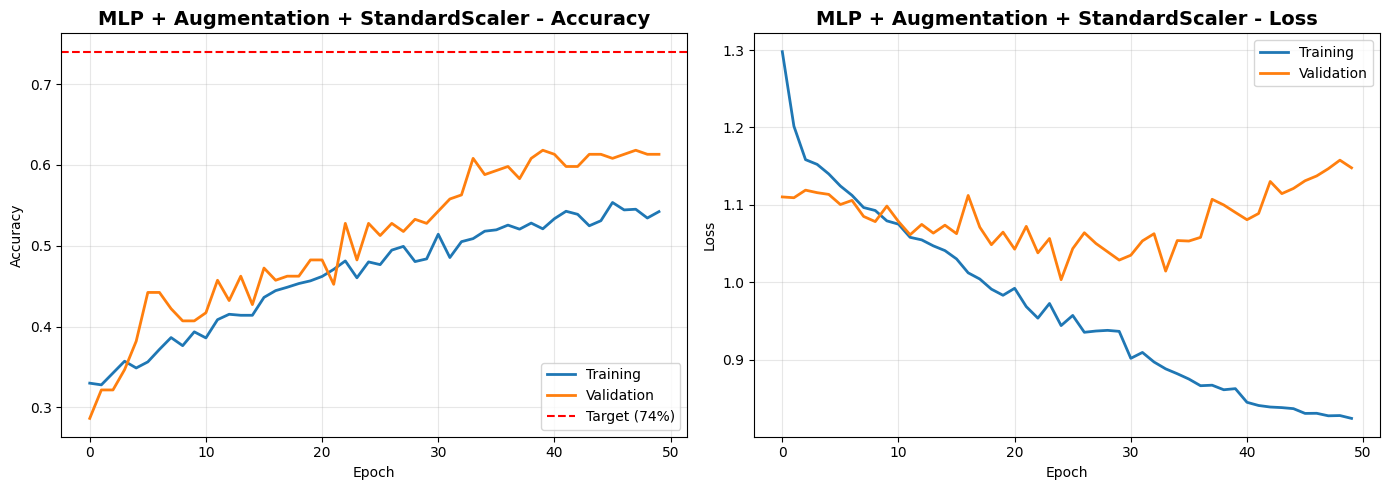

Best val accuracy: 61.81% at epoch 40


In [14]:
mlp_aug_model = build_mlp_model(X_train_aug_scaled.shape[1], NUM_CLASSES)
compile_model(mlp_aug_model)
callbacks_aug = get_callbacks()

print("="*70)
print("TRAINING MLP + DATA AUGMENTATION (with StandardScaler)")
print("="*70)

history_mlp_aug = mlp_aug_model.fit(
    X_train_aug_scaled, y_train_aug,
    validation_data=(X_val_aug_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_aug,
    verbose=1
)

_, mlp_aug_val_acc = mlp_aug_model.evaluate(X_val_aug_scaled, y_val, verbose=0)
print(f"\nMLP + Augmentation Validation Accuracy: {mlp_aug_val_acc:.2%}")
plot_history(history_mlp_aug, title="MLP + Augmentation + StandardScaler")

## 8. MLP + HOG Features (with StandardScaler)

In [15]:
print("Extracting HOG features...")
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)

print(f"Original features: {X_train_flat.shape[1]:,}")
print(f"HOG features: {X_train_hog.shape[1]:,}")

# Apply StandardScaler to HOG features
print("\nApplying StandardScaler to HOG features...")
X_train_hog_scaled, X_val_hog_scaled, X_test_hog_scaled, scaler_hog = apply_standard_scaler(
    X_train_hog, X_val_hog, X_test_hog
)

Extracting HOG features...
Original features: 150,528
HOG features: 6,084

Applying StandardScaler to HOG features...


TRAINING MLP + HOG FEATURES (with StandardScaler)
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.5100 - loss: 1.0724 - val_accuracy: 0.5427 - val_loss: 1.1289 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7807 - loss: 0.5719 - val_accuracy: 0.6884 - val_loss: 0.8678 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8784 - loss: 0.3435 - val_accuracy: 0.7286 - val_loss: 0.7624 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9323 - loss: 0.2103 - val_accuracy: 0.7538 - val_loss: 0.7939 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9624 - loss: 0.1239 - val_accuracy: 0.7236 - val_loss: 0.8159 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9662 - loss: 0.1124 - val_accuracy: 0.7286 - val_loss: 0.8609 - learning_rate: 0.0010
Epoch 7/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22m

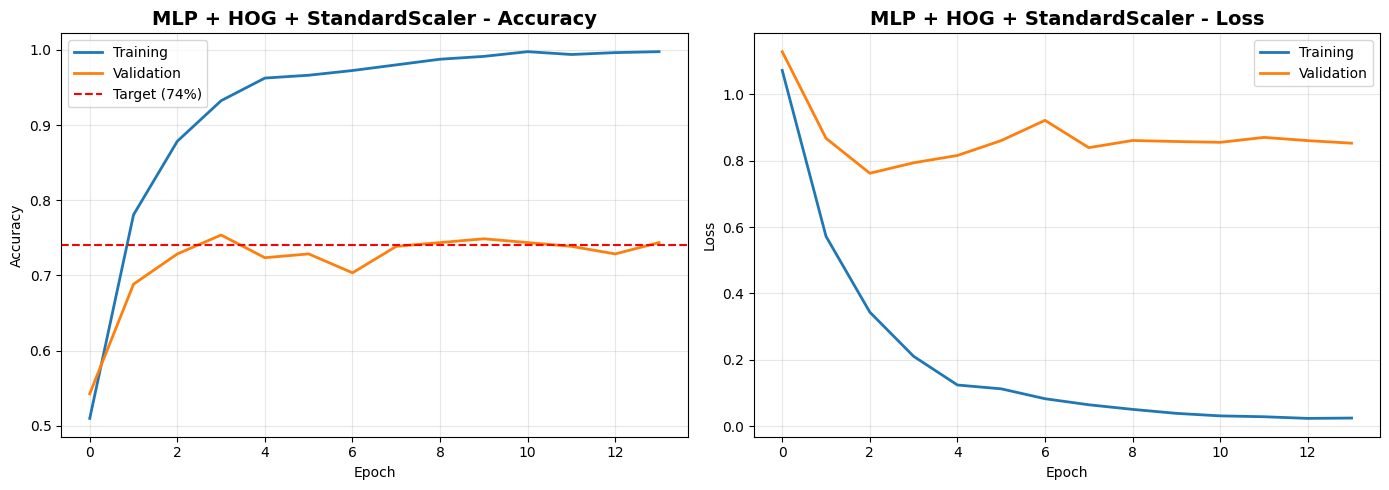

Best val accuracy: 75.38% at epoch 4


In [16]:
mlp_hog_model = build_mlp_model(X_train_hog_scaled.shape[1], NUM_CLASSES)
compile_model(mlp_hog_model)
callbacks_hog = get_callbacks()

print("="*70)
print("TRAINING MLP + HOG FEATURES (with StandardScaler)")
print("="*70)

history_mlp_hog = mlp_hog_model.fit(
    X_train_hog_scaled, y_train,
    validation_data=(X_val_hog_scaled, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_hog,
    verbose=1
)

_, mlp_hog_val_acc = mlp_hog_model.evaluate(X_val_hog_scaled, y_val, verbose=0)
print(f"\nMLP + HOG Validation Accuracy: {mlp_hog_val_acc:.2%}")
plot_history(history_mlp_hog, title="MLP + HOG + StandardScaler")

## 9. CNN Model

In [17]:
cnn_model = build_cnn_model((IMG_H, IMG_W, 3), NUM_CLASSES)
cnn_model.summary()

Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_9                │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_9 (Activation)            │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_10               │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_10 (Activation)           │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_11               │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_11 (Activation)           │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_12               │ (None, 28, 28, 256)         │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_12 (Activation)           │ (None, 28, 28, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │              

 Total params: 457,923 (1.75 MB)

 Trainable params: 456,451 (1.74 MB)

 Non-trainable params: 1,472 (5.75 KB)

TRAINING CNN
Epoch 1/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 33s 608ms/step - accuracy: 0.3810 - loss: 1.3541 - val_accuracy: 0.3367 - val_loss: 1.1027 - learning_rate: 0.0010
Epoch 2/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 593ms/step - accuracy: 0.3847 - loss: 1.3252 - val_accuracy: 0.3367 - val_loss: 1.2211 - learning_rate: 0.0010
Epoch 3/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 590ms/step - accuracy: 0.3747 - loss: 1.2540 - val_accuracy: 0.3367 - val_loss: 1.4267 - learning_rate: 0.0010
Epoch 4/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 596ms/step - accuracy: 0.4398 - loss: 1.1701 - val_accuracy: 0.3367 - val_loss: 1.4499 - learning_rate: 0.0010
Epoch 5/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 599ms/step - accuracy: 0.4323 - loss: 1.2091 - val_accuracy: 0.2965 - val_loss: 1.1865 - learning_rate: 0.0010
Epoch 6/90
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.4085 - loss: 1.1613
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
50/50 ━━━━━━━━━━━━━━━━━━━━ 30s 603ms/step - accuracy: 0.4286

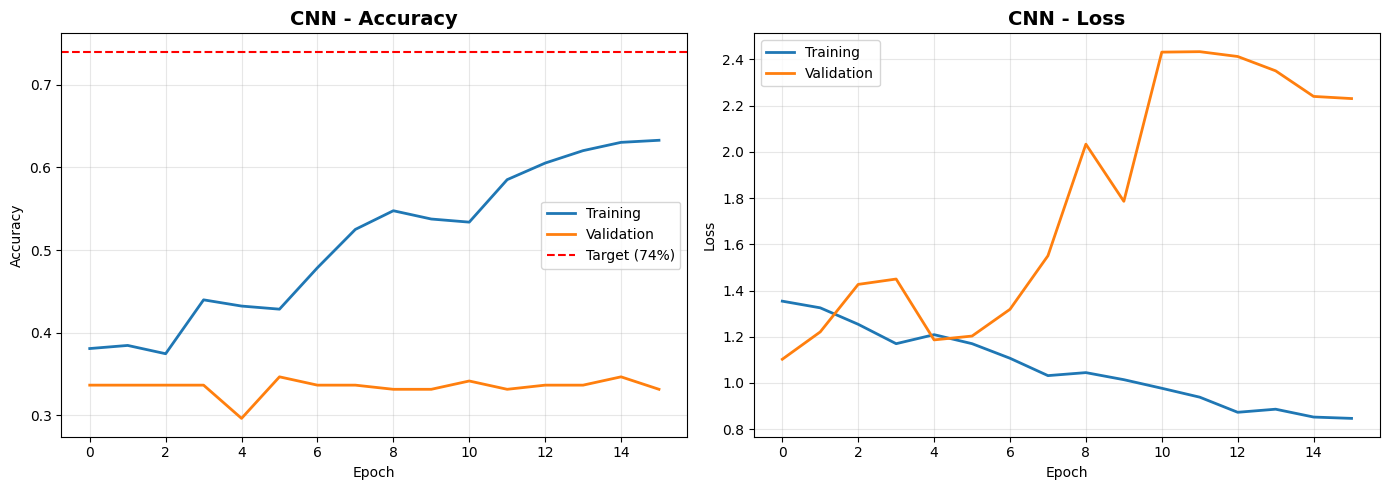

Best val accuracy: 34.67% at epoch 6


In [18]:
compile_model(cnn_model)
callbacks_cnn = get_callbacks()

print("="*70)
print("TRAINING CNN")
print("="*70)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_cnn,
    verbose=1
)

_, cnn_val_acc = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"\nCNN Validation Accuracy: {cnn_val_acc:.2%}")
plot_history(history_cnn, title="CNN")

## 10. Transfer Learning (MobileNetV2)

In [19]:
transfer_model = build_transfer_model(NUM_CLASSES, input_shape=(IMG_H, IMG_W, 3))
transfer_model.summary()

Model: "TransferLearning_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ multiply (Multiply)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ true_divide (TrueDivide)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ subtract (Subtract)                  │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 256)                 │         327,936 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_14               │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_14 (Activation)           │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 3)                   │             771 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,587,715 (9.87 MB)

 Trainable params: 329,219 (1.26 MB)

 Non-trainable params: 2,258,496 (8.62 MB)

TRAINING TRANSFER LEARNING (MobileNetV2)
Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 222ms/step - accuracy: 0.4398 - loss: 1.3000 - val_accuracy: 0.5879 - val_loss: 0.8655 - learning_rate: 1.0000e-04
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 201ms/step - accuracy: 0.7030 - loss: 0.7165 - val_accuracy: 0.7839 - val_loss: 0.6160 - learning_rate: 1.0000e-04
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 207ms/step - accuracy: 0.7707 - loss: 0.5279 - val_accuracy: 0.8442 - val_loss: 0.4829 - learning_rate: 1.0000e-04
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.8346 - loss: 0.4452 - val_accuracy: 0.8693 - val_loss: 0.4115 - learning_rate: 1.0000e-04
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.8609 - loss: 0.3583 - val_accuracy: 0.8794 - val_loss: 0.3740 - learning_rate: 1.0000e-04
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 210ms/step - accuracy: 0.8947 - loss: 0.3029 - val_accuracy: 0.9045 - val_loss: 0.3438 - learning_rate: 1.0000e-04
Epoch 7/50
50/50 

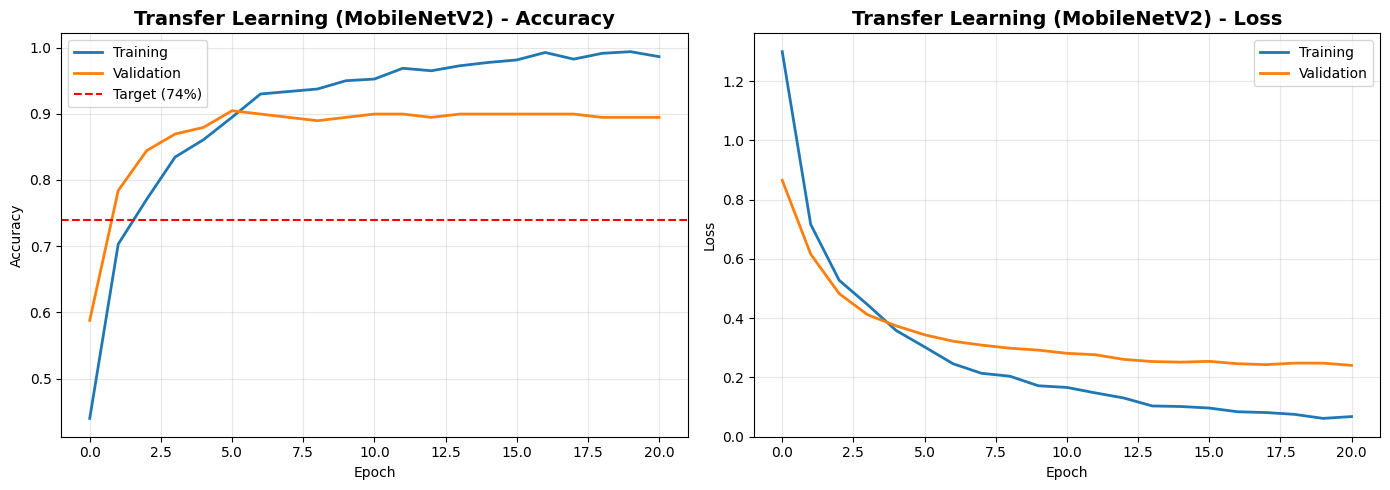

Best val accuracy: 90.45% at epoch 6


In [20]:
compile_model(transfer_model, learning_rate=0.0001)
callbacks_transfer = get_callbacks(patience=15)

print("="*70)
print("TRAINING TRANSFER LEARNING (MobileNetV2)")
print("="*70)

history_transfer = transfer_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_transfer,
    verbose=1
)

_, transfer_val_acc = transfer_model.evaluate(X_val, y_val, verbose=0)
print(f"\nTransfer Learning Validation Accuracy: {transfer_val_acc:.2%}")
plot_history(history_transfer, title="Transfer Learning (MobileNetV2)")

## 11. Final Comparison


FINAL MODEL COMPARISON
              Model  Validation Accuracy (%)
  Transfer Learning                90.452260
          MLP + HOG                75.376886
     MLP (Baseline)                63.819093
Logistic Regression                61.809045
 MLP + Augmentation                61.809045
      Decision Tree                46.733668
                CNN                34.673366


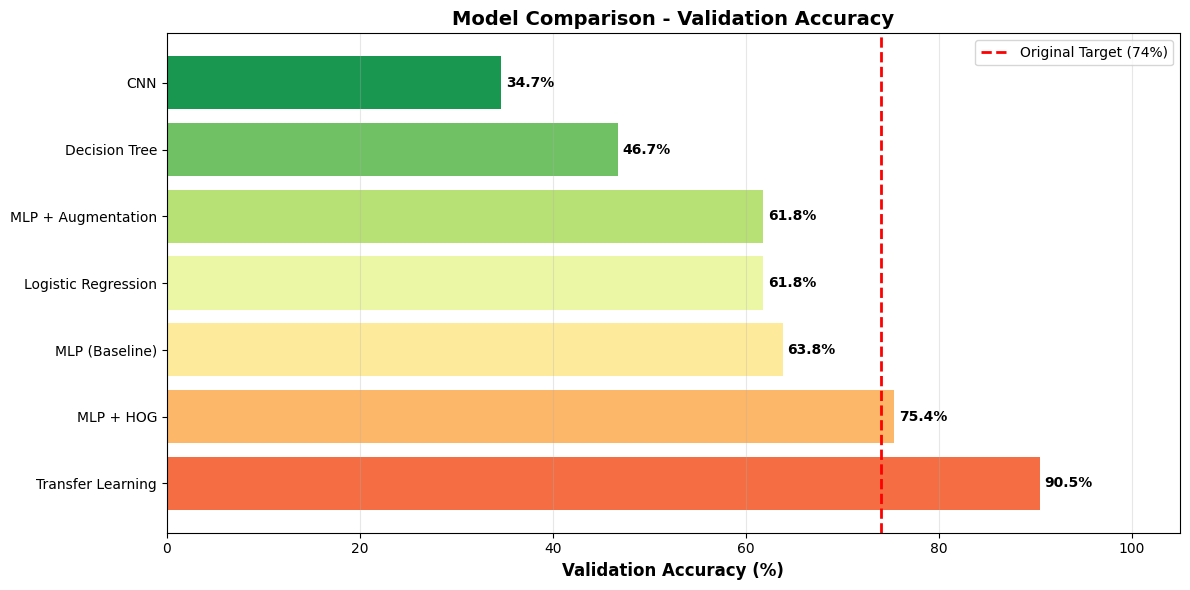

In [21]:
results = pd.DataFrame({
    'Model': [
        'Decision Tree',
        'Logistic Regression',
        'MLP (Baseline)',
        'MLP + Augmentation',
        'MLP + HOG',
        'CNN',
        'Transfer Learning'
    ],
    'Validation Accuracy (%)': [
        dt_acc * 100,
        lr_acc * 100,
        mlp_val_acc * 100,
        mlp_aug_val_acc * 100,
        mlp_hog_val_acc * 100,
        cnn_val_acc * 100,
        transfer_val_acc * 100,
    ],
})

results = results.sort_values('Validation Accuracy (%)', ascending=False).reset_index(drop=True)

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(results.to_string(index=False))
print("="*70)

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results)))
bars = ax.barh(results['Model'], results['Validation Accuracy (%)'], color=colors)
ax.axvline(x=74, color='red', linestyle='--', linewidth=2, label='Original Target (74%)')
ax.set_xlabel('Validation Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Comparison - Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, 105)

for bar, val in zip(bars, results['Validation Accuracy (%)']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', ha='left', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## 12. Evaluate Best Model

Best model: Transfer Learning

VALIDATION RESULTS
Validation Accuracy: 90.45%

              precision    recall  f1-score   support

       paper       0.92      0.85      0.88        67
        rock       0.94      0.99      0.96        67
     scissor       0.85      0.88      0.86        65

    accuracy                           0.90       199
   macro avg       0.90      0.90      0.90       199
weighted avg       0.90      0.90      0.90       199


TEST RESULTS
Test Accuracy: 88.00%

              precision    recall  f1-score   support

       paper       0.88      0.88      0.88         8
        rock       0.89      1.00      0.94         8
     scissor       0.88      0.78      0.82         9

    accuracy                           0.88        25
   macro avg       0.88      0.88      0.88        25
weighted avg       0.88      0.88      0.88        25



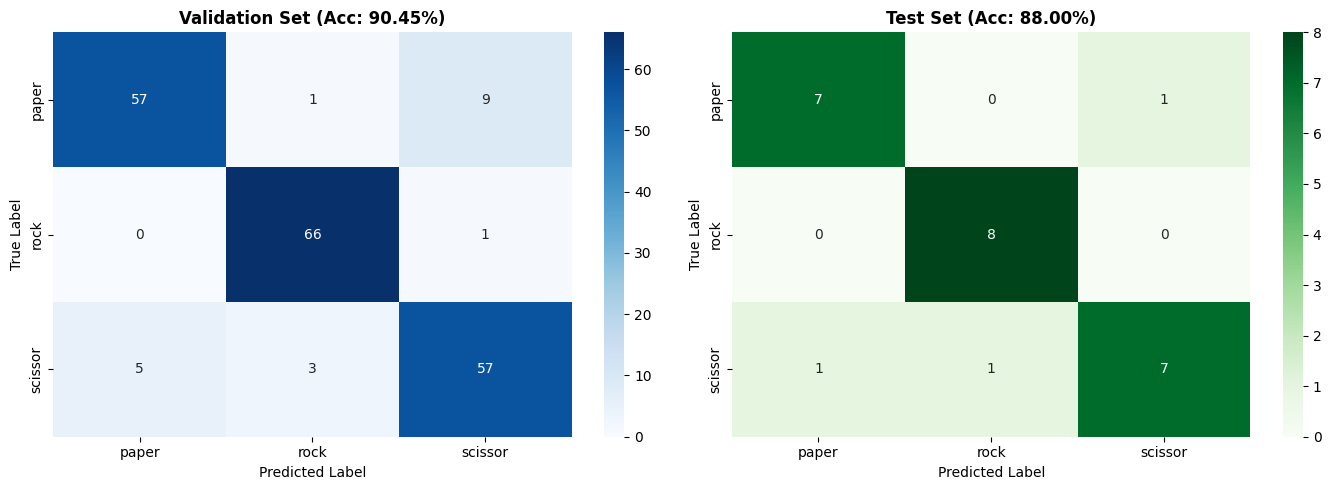

In [22]:
best_model_name = results.iloc[0]['Model']
print(f"Best model: {best_model_name}")

# Evaluate best model with confusion matrix
if best_model_name == 'Transfer Learning':
    best_model = transfer_model
    X_val_input, X_test_input = X_val, X_test
elif best_model_name == 'CNN':
    best_model = cnn_model
    X_val_input, X_test_input = X_val, X_test
elif best_model_name == 'MLP + HOG':
    best_model = mlp_hog_model
    X_val_input, X_test_input = X_val_hog_scaled, X_test_hog_scaled
elif best_model_name == 'MLP + Augmentation':
    best_model = mlp_aug_model
    X_val_input, X_test_input = X_val_aug_scaled, X_test_aug_scaled
else:
    best_model = mlp_model
    X_val_input, X_test_input = X_val_scaled, X_test_scaled

evaluate_model(best_model, X_val_input, y_val, X_test_input, y_test, CLASSES)

## 13. Save Best Model

In [23]:
best_model.save('rps_best_model.keras')
print(f"Best model ({best_model_name}) saved as: rps_best_model.keras")

Best model (Transfer Learning) saved as: rps_best_model.keras
